Data Processing

In [23]:
import pandas as pd
Patients = pd.read_csv('patients.csv')
Diagnosis = pd.read_csv('diagnoses.csv')
Outcomes = pd.read_csv('outcomes.csv')
Labs = pd.read_csv('labs.csv')

In [24]:
Patients = Patients.merge(Diagnosis, on='DiagnosisID')
Patients = Patients.merge(Outcomes, on='OutcomeID')

In [25]:
Patients['AdmissionDate'] = pd.to_datetime(Patients['AdmissionDate'])
Patients['DischargeDate'] = pd.to_datetime(Patients['DischargeDate'])
Patients['LengthOfStay'] = (Patients['DischargeDate'] - Patients['AdmissionDate']).dt.days

In [26]:
Patients['OutcomeEmcoded'] = Patients['OutcomeName'].map({'Recovered':0, 'Complicated':1, 'Deceased':1})

Creating High Risk Indicator

In [27]:
import numpy as np

Patients['HighRisk'] = np.where((Patients['Age'] > 65) | (Patients['OutcomeName'].isin(['Complicated', 'Deceased'])),1,0)

In [28]:
abnormal_conditions = {
    'Blood Sugar': lambda x: x>120,
    'Cholesterol': lambda x: x>200,
    'Hemoglobin': lambda x: x<13
}

def count_abnormal_labs(patient_id):
    patient_labs = Labs[Labs['PatientID'] == patient_id]
    count = 0
    for test_name, condition in abnormal_conditions.items():
        test_results = patient_labs[patient_labs['TestName'] == test_name]
        count += test_results['Result'].apply(condition).sum()
    return count

Patients['AbnormalLabCount'] = Patients['PatientID'].apply(count_abnormal_labs)

Model Training


In [29]:
feature = Patients[['Age', 'LengthOfStay', 'TreatmentCost']]
target = Patients['OutcomeEmcoded']

In [30]:
from sklearn.model_selection import train_test_split
x_train, x_test, y_train, y_test = train_test_split(feature, target, test_size= 0.2, random_state= 42)

In [31]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression (max_iter= 500)
model.fit(x_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [32]:
from sklearn.metrics import classification_report, confusion_matrix
y_pred = model.predict(x_test)
print("Classification Report: ")
print(classification_report(y_test,y_pred))

Classification Report: 
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        12
           1       0.70      1.00      0.82        28

    accuracy                           0.70        40
   macro avg       0.35      0.50      0.41        40
weighted avg       0.49      0.70      0.58        40



C:\Users\jayes\AppData\Roaming\Python\Python313t\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jayes\AppData\Roaming\Python\Python313t\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
C:\Users\jayes\AppData\Roaming\Python\Python313t\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capi

Roc Curve

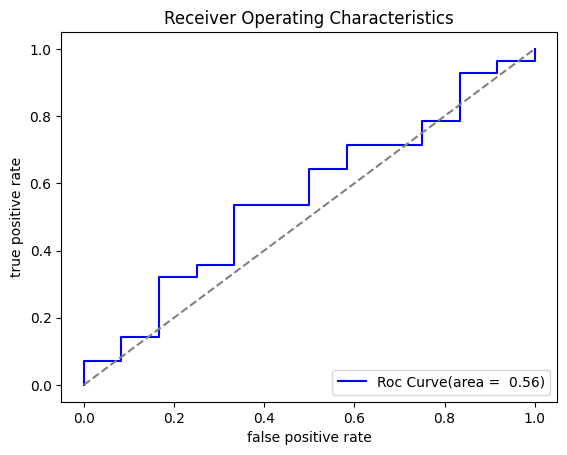

In [33]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
y_prob = model.predict_proba(x_test)[:,1]
fpr ,tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr,tpr)
plt.figure()
plt.plot( fpr, tpr, color= 'blue', label= f'Roc Curve(area = {roc_auc : .2f})')
plt.plot([0,1], [0,1], color= 'gray', linestyle= '--')
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.title('Receiver Operating Characteristics')
plt.legend(loc = "lower right")
plt.show()

In [34]:
import joblib

joblib.dump(model, "risk_model.pkl")

['risk_model.pkl']